# Deutsch-Jozsa Algorithm

In this notebook, we will implement the Deutsch-Jozsa algorithm using Qiskit. The Deutsch-Jozsa algorithm is a quantum algorithm that determines whether a given function is constant or balanced with a single query, showcasing the power of quantum computing over classical methods.
We are going to follow the IBM Quantum Learning Guide [Deutsch-Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm).

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

## The Oracle Function

The dj_query function constructs the oracle for the Deutsch-Jozsa algorithm promising it will be a function that is either constant or balanced (50/50). 

It takes a list of bits as input, where each bit represents whether the corresponding input to the function should flip the output qubit (1 for flip, 0 for no flip). The function creates a quantum circuit that applies CNOT gates from each input qubit to the output qubit based on the provided bits.

In [ ]:
def dj_query(num_qubits):
    """
    Create a circuit implementing for a query gate for a random function satisfying the
    promise for the Deutsch-Jozsa problem.
    Args:
        num_qubits (int): number of qubits in the input register
    Returns:
        QuantumCircuit: a circuit implementing the query gate for a random function
    """
    qc = QuantumCircuit(num_qubits + 1)

    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance
        return qc

    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc

    for state in on_states:
        qc.barrier()  # Barriers added to help visualize how the functions are created.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    qc.barrier()

    return qc

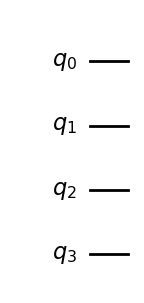

In [3]:
display(dj_query(3).draw(output="mpl"))

## Deutsch-Jozsa Circuit Implementation

In [ ]:
def compile_dj_circuit(function: QuantumCircuit):
    """Compiles a circuit for use in the Deutsch-Jozsa algorithm.

    Args:
        function (QuantumCircuit): The query circuit to compile.

    Returns:
        QuantumCircuit: The compiled circuit.
    """
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(function, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

In [ ]:
def dj_algorithm(function: QuantumCircuit):
    """Determine if a function is constant or balanced.

    Args:
        function (QuantumCircuit): The query circuit for the function to test.

    Returns:
        str: "constant" if the function is constant, "balanced" if the function is
        balanced.
    """

    qc = compile_dj_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

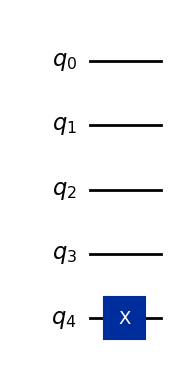

'constant'

In [6]:
f = dj_query(4)
display(f.draw("mpl"))
display(dj_algorithm(f))